## Logistic Regression

Logistic regression is a linear classification model that estimates class probabilities by modeling the log-odds of the response as a linear function of the input features. In the binary case, probabilities are produced through the logistic (sigmoid) function; in the multiclass setting, the softmax function is used. This probabilistic formulation makes logistic regression both interpretable and suitable for applications where calibrated class probabilities are important.

Regularization plays a central role in controlling model complexity. By default, the model uses **L2 regularization**, which penalizes the squared magnitude of coefficients. L2 regularization shrinks coefficients toward zero but does not force exact zeros, helping reduce variance while retaining all features. Alternatively, **L1 regularization** (Lasso) penalizes the absolute value of coefficients, which can drive some coefficients exactly to zero and perform implicit feature selection. When using the **elastic net** penalty, both L1 and L2 terms are combined, and the `l1_ratio` parameter controls the proportion of L1 versus L2 contribution.

The regularization strength is governed by the parameter *C*, which is the inverse of the penalty magnitude. Smaller values of *C* correspond to stronger regularization and greater coefficient shrinkage, increasing bias but potentially improving generalization. Larger values of *C* reduce the strength of regularization, allowing the model to fit the training data more closely and increasing variance. Careful tuning of *C*, and when applicable the choice of penalty type and `l1_ratio`, allows control over the bias–variance tradeoff in linear classification.


In [16]:
from sklearn.linear_model import LogisticRegression


example = LogisticRegression(
    penalty='l2', # default='l2' - options: 'l1', 'l2', 'elasticnet', 'none' - used to specify the norm used in the penalization
    dual=False, # default=False - dual or primal formulation
    tol=0.0001, # default=0.0001 - tolerance for stopping criteria
    C=1.0, # default=1.0 - inverse of regularization strength
    fit_intercept=True, # default=True - whether to calculate the intercept for this model
    intercept_scaling=1, # default=1 - useful only when the solver 'liblinear' is used and self.fit_intercept is set to True
    class_weight=None, # default=None - weights associated with classes
    random_state=None, # default=None - seed of the pseudo random number generator to use when shuffling the data
    solver='lbfgs', # default='lbfgs' - algorithm to use in the optimization problem
    max_iter=100, # default=100 - maximum number of iterations taken for the solvers to converge
    multi_class='deprecated', # default='deprecated' - if the option chosen is 'ovr', then a binary problem is fit for each label. Else the loss minimised is the multinomial loss fit across the entire probability distribution, even when the data is binary.
    verbose=0, # default=0 - For the liblinear and lbfgs solvers set verbose to any positive number for verbosity.
    warm_start=False, # default=False - when set to True, reuse the solution of the previous call to fit as initialization, otherwise, just erase the previous solution.
    n_jobs=None, # default=None - Number of CPU cores used when parallelizing over classes if multi_class='ovr'". -1 means using all processors.
    l1_ratio=None, # default=None - The Elastic-Net mixing parameter, with 0 <= l1_ratio <= 1. Only used if penalty='elasticnet'.
)

In [17]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc
import matplotlib.pyplot as plt

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

In [18]:
splits = np.load("data/iris_splits.npz", allow_pickle=True)

X_sepal_train_std = splits["X_sepal_train_std"]
X_sepal_test_std  = splits["X_sepal_test_std"]
X_petal_train_std = splits["X_petal_train_std"]
X_petal_test_std  = splits["X_petal_test_std"]
X_train_combined = splits["X_train_combined"]
X_test_combined  = splits["X_test_combined"]
y_train = splits["y_train"]
y_test  = splits["y_test"]

In [19]:
import sys
sys.path.append("src")

from utils import plot_decision_regions

In [20]:
model = LogisticRegression(C = 10) # default C = 1
model.fit(X_train_combined, y_train)
y_pred = model.predict(X_test_combined)
print("Combined Features Logistic Regression")
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Combined Features Logistic Regression
Test Accuracy: 1.0
Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30

Confusion Matrix:
 [[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]


Default *C=1* resulted in 2 misclassifications, where tuning achieved 100% accuracy. A larger C allows for a more complex model, increasing the variance. 

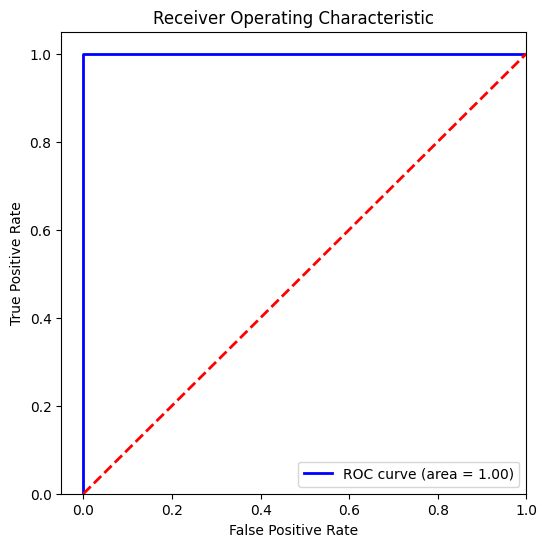

In [21]:
y_test_bin = label_binarize(y_test, classes=model.classes_)

fpr, tpr, thresholds = roc_curve(
    y_test_bin[:, 1],  # choose class index
    model.predict_proba(X_test_combined)[:, 1]
)

roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (area = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlim([-0.05, 1.0])   
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [22]:
feature_names = [
    "SepalLength",
    "SepalWidth",
    "PetalLength",
    "PetalWidth"
]

coefficients = model.coef_

coef_df = pd.DataFrame(
    coefficients,
    columns=feature_names,
    index=model.classes_
)

print(coef_df)

                 SepalLength  SepalWidth  PetalLength  PetalWidth
Iris-setosa        -1.804435    1.713210    -3.307377   -3.195644
Iris-versicolor     1.136686   -0.288714    -1.150083   -1.438540
Iris-virginica      0.667749   -1.424496     4.457460    4.634184


In [23]:
model = LogisticRegression()
model.fit(X_petal_train_std, y_train)
y_pred = model.predict(X_petal_test_std)
print("Petal Features Logistic Regression")
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Petal Features Logistic Regression
Test Accuracy: 0.9333333333333333
Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30

Confusion Matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


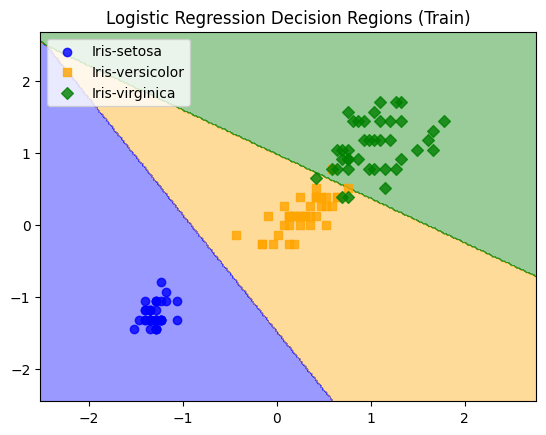

In [24]:
plot_decision_regions(X_petal_train_std, y_train, model)
plt.title("Logistic Regression Decision Regions (Train)")
plt.show()

In [25]:
model = LogisticRegression()
model.fit(X_sepal_train_std, y_train)
y_pred = model.predict(X_sepal_test_std)
print("Sepal Features Logistic Regression")
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Sepal Features Logistic Regression
Test Accuracy: 0.7333333333333333
Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.62      0.50      0.56        10
 Iris-virginica       0.58      0.70      0.64        10

       accuracy                           0.73        30
      macro avg       0.74      0.73      0.73        30
   weighted avg       0.74      0.73      0.73        30

Confusion Matrix:
 [[10  0  0]
 [ 0  5  5]
 [ 0  3  7]]


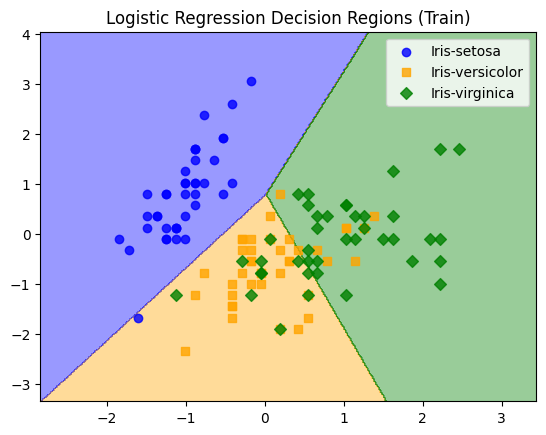

In [26]:
plot_decision_regions(X_sepal_train_std, y_train, model)
plt.title("Logistic Regression Decision Regions (Train)")
plt.show()

# Conclusion

Logistic Regression produced results similar to the linear SVM when using default parameters, with a small performance gap and minor misclassification in the overlapping classes. After tuning the regularization parameter from the default *C=1* to *C=10*, test accuracy improved from two misclassifications to none. The improvement occurred primarily at the class boundary, while coefficient magnitudes did not change substantially.

Increasing *C* reduced regularization strength, decreasing bias and allowing the model to better fit the training data. This adjustment illustrates how even a single tuning parameter can meaningfully influence classification performance. Compared to other models, Logistic Regression required relatively simple tuning due to having fewer primary hyperparameters.

These results emphasize that default settings provide reasonable starting points but should not be treated as optimal. Understanding how regularization strength affects bias–variance tradeoff is essential when applying linear models in future projects.